In [1]:
import matplotlib.pyplot as plt
import numpy as np

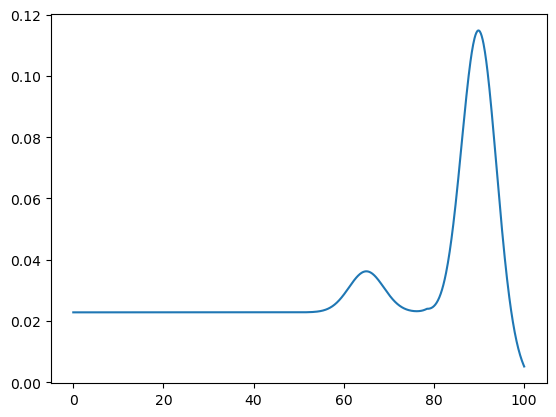

In [14]:
import numpy as np

def get_parameters():
    """Return the parameters from Table 3"""
    return {
        'a1': 0.5,
        'a2': 0.015,  # keV^-1
        'a3': 0.042,  # keV^-1
        'a4': 0.213e-3,  # keV^-2
        'a5': 1.61,   # keV
        'a6': 0.025
    }

def c2(E, Ee, a1, a2):
    """
    Piecewise function for c2(E)
    E: energy in keV
    Ee: escape energy (~25 keV for CdTe)
    """
    return np.where(E > Ee, a1 * np.exp(-a2 * E), 0)

def c3(E, a3, a4):
    """Linear function for c3(E)"""
    return a3 - a4 * E

def sigma(E, a5, a6):
    """Linear function for σ(E)"""
    return a5 + a6 * E

def background(U, E, c3_val, sigma_val):
    """
    Calculate background B(U,E)
    - Constant value of c3 for U < (E - 3σ₁)
    - Linearly ramped down to zero within width of 6σ₁
    """
    threshold = E - 3 * sigma_val
    ramp_width = 6 * sigma_val
    
    # Create the piecewise function
    background = np.where(
        U < threshold,
        c3_val,  # constant value below threshold
        np.where(
            U < threshold + ramp_width,
            # Linear ramp from c3 to 0 over 6σ₁ width
            c3_val * (1 - (U - threshold) / ramp_width),
            0  # zero above threshold + ramp_width
        )
    )
    return background

def response_function(U, E, c1):
    """
    Calculate the response function R(U,E) with the specific parameters from the paper
    
    Parameters:
    U : float or array-like
        Measured energy (keV)
    E : float or array-like
        Incident energy (keV)
    c1 : float or callable
        First coefficient (preserves number of photons of incoming flux)
    
    Returns:
    float or array-like: The calculated response value(s)
    """
    # Get parameters
    params = get_parameters()
    Ee = 25.0  # escape energy for CdTe in keV
    
    # Calculate coefficients
    c1_val = c1(E) if callable(c1) else c1
    c2_val = c2(E, Ee, params['a1'], params['a2'])
    c3_val = c3(E, params['a3'], params['a4'])
    
    # Calculate sigma (same for both terms)
    sigma_val = sigma(E, params['a5'], params['a6'])
    
    # Calculate the Gaussian terms
    gaussian1 = (1 / (np.sqrt(2*np.pi) * sigma_val)) * \
                np.exp(-0.5 * ((U - E)**2) / (sigma_val**2))
    
    # For escape peak, shift energy by Ee
    gaussian2 = (1 / (np.sqrt(2*np.pi) * sigma_val)) * \
                np.exp(-0.5 * ((U - (E - Ee))**2) / (sigma_val**2))
    
    # Calculate background term
    B = background(U, E, c3_val, sigma_val)
    
    # Combine all terms
    result = c1_val * gaussian1 + c2_val * gaussian2 + B
    
    return result
energies = np.linspace(0, 100, 1000)
response = response_function(energies, 90, 1)
plt.figure()
plt.plot(energies, response)